In [1]:
"""
This script performs virtual perturbation on the Ma2024Aging dataset,
"""
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import anndata as ad

import sys
sys.path.append("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/brainbeacon")
from model_cdniche.pipeline.cell_embedding import run_bbcellformer_pipeline
from model_cdniche.pipeline.perturbation import inject_cells_randomly, inject_cells_theory, plot_cosine_to_centroids_with_perturb
from model_cdniche.pipeline.perturbation import analyze_embedding_similarity_change, analyze_gene_reconstruction_change, compute_delta_cosine
from model_cdniche.utils import set_seed
from config.config_cdniche import GENE_DICT_PATH
from config.config_train_cdniche import config_train
from model_cdniche.utils import compute_density_token, compute_deviation_bin_rapid_v2
from model_cdniche.utils import convert_spatial_to_um, platform_radius_map
import logging

logging.basicConfig(
    level=logging.INFO,  # 或 level=logging.DEBUG
    format='%(asctime)s %(levelname)s %(message)s'
)

import warnings

warnings.filterwarnings("ignore")
set_seed(42)

In [2]:
# Set GPU 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

# Define base paths and dataset info
BASE_DIR = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/"
adata_path = os.path.join(BASE_DIR, "data", "adata_outer_ensembl.h5ad")

Using device: cuda
Using GPU: NVIDIA H800


In [3]:

# ========== 1. Dataset and Basic Setup ==========
dataset_name = "ma2024aging_niche2cell"
specie = "mouse"
assay = "stereo"

# ========== 3. Pretrained Checkpoints ==========
bb_ckpt_path   = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt"
cellplm_ckpt_path_global = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt"
gene_dict_path = GENE_DICT_PATH
gene_mean_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/stereo-seq_gene_nonzero_means_metacell_2.npy"

# ========== 4. Output Naming ==========
cd_weight = 0.02
use_hvg = True
# use_hvg = False
n_hvg = 5000
output_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp"

# ========== 5. Select and Save Slices ==========
# Select two target slices and save filtered AnnData to output directory
full_adata = sc.read_h5ad(adata_path)

selected_slices = ["Hippocampus_Y_2_1", "Hippocampus_O_2_1"]
# adata = full_adata[full_adata.obs["slice"].isin(selected_slices)].copy()
adata = full_adata.copy()
# 自动根据 slice 名称设置 Young / Old
def infer_cell_label(slice_name: str) -> str:
    if slice_name.startswith("Hippocampus_Y"):
        return "Young"
    elif slice_name.startswith("Hippocampus_O"):
        return "Old"
    else:
        return None  # 若还有其他未知 slice，可选设为 None 或 raise 错误

# 应用函数到每个 obs 的 slice
adata.obs["cell_label"] = adata.obs["slice"].apply(infer_cell_label)
adata.obs["batch"] = adata.obs["slice"]
# 显式声明类别为 Categorical 类型，仅限 Young 和 Old
adata.obs["cell_label"] = pd.Categorical(
    adata.obs["cell_label"],
    categories=["Young", "Old"]
)

In [4]:
out_fig_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig5_subfig"
os.makedirs(out_fig_dir, exist_ok=True)

1.0 118.0 1.0 63.0
AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'lognorm', 'raw_count'


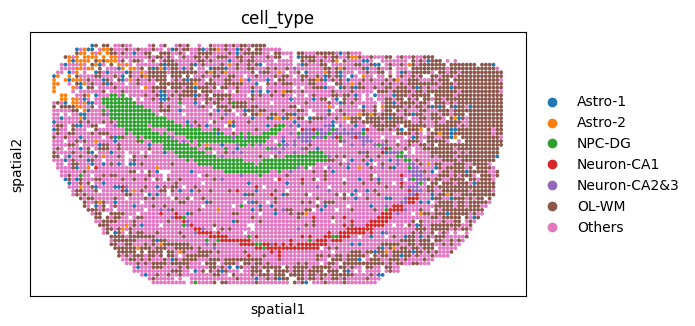

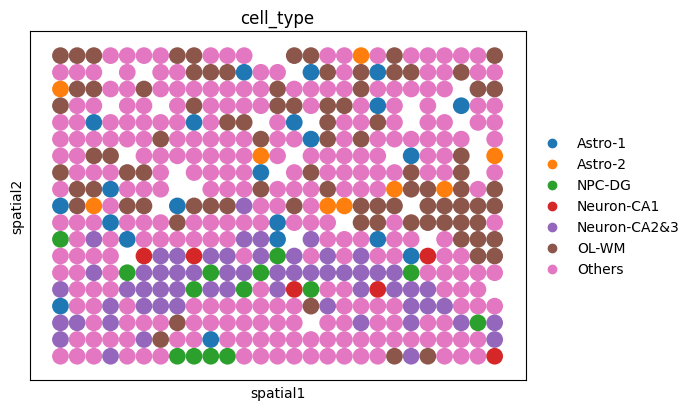

In [5]:
# 1. 设定 OL-WM 区域
adata_O = adata[adata.obs["slice"] == "Hippocampus_O_2_1", :]
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1", :]
# ol_cells = adata_O[adata_O.obs["cell_type"] == "NPC-DG"]
ol_cells = adata_O.copy()
# 2. 观察 spatial 坐标范围，挑右上角
x = ol_cells.obsm["spatial"][:, 0]
y = ol_cells.obsm["spatial"][:, 1]
print(x.min(), x.max(), y.min(), y.max())

ol_roi = ol_cells[
    (ol_cells.obsm["spatial"][:, 0] > 60) &    # x > 13 → 靠右
    (ol_cells.obsm["spatial"][:, 1] > 10) &    # y > 30
    (ol_cells.obsm["spatial"][:, 0] < 88) &      # y < 70 → 上下界
    (ol_cells.obsm["spatial"][:, 1] < 30)
].copy()
print(ol_roi)
# 提取默认颜色映射
# 先用默认配色绘制 ol_cells
sc.pl.spatial(ol_cells, color="cell_type", spot_size=1)

# 提取默认颜色映射
# 1. 把 cell_type 转成分类类型并设置顺序
ol_roi.obs["cell_type"] = pd.Categorical(
    ol_roi.obs["cell_type"],
    categories=ol_cells.obs["cell_type"].cat.categories,  # 保持顺序一致
    ordered=True
)

# 2. 同步颜色
ol_roi.uns["cell_type_colors"] = ol_cells.uns["cell_type_colors"]

# 3. 绘图
sc.pl.spatial(ol_roi, color="cell_type", spot_size=1)


x: 1.0 ~ 85.0, y: 1.0 ~ 52.0
ROI cells: 495


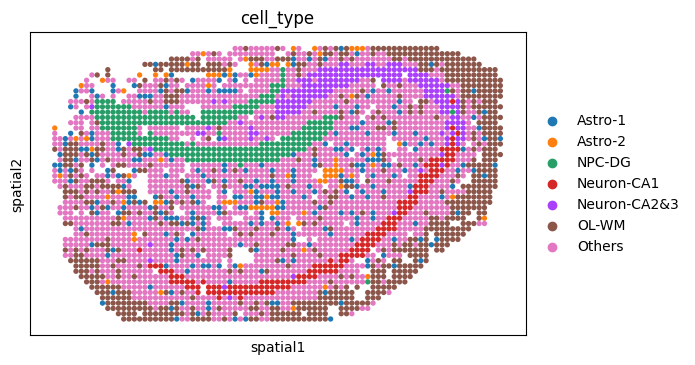

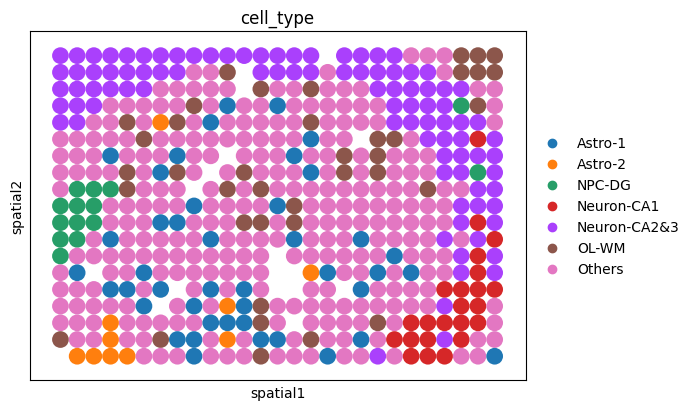

In [6]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import logging

# === Step 0: Matplotlib 设置，确保 PDF 可编辑 & 字体一致 ===
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True
plt.rcParams['pdf.fonttype'] = 42  # 确保 AI/Illustrator 可编辑字体
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

# === Step 1: 提取切片 ===
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1"].copy()

# === Step 2: 获取 spatial 坐标 ===
x = adata_Y.obsm["spatial"][:, 0]
y = adata_Y.obsm["spatial"][:, 1]
print(f"x: {x.min():.1f} ~ {x.max():.1f}, y: {y.min():.1f} ~ {y.max():.1f}")

# === Step 3: 定义 ROI 区域 (右上角)
roi_mask = (x > 50) & (x < 78) & (y > 5) & (y < 25)
y_roi = adata_Y[roi_mask].copy()
print(f"ROI cells: {y_roi.shape[0]}")

# === Step 4: 同步细胞类型的分类顺序和颜色 ===
# 设置 cell_type 为分类类型，并同步类别顺序
adata_Y.obs["cell_type"] = adata_Y.obs["cell_type"].astype("category")
categories = adata_Y.obs["cell_type"].cat.categories
y_roi.obs["cell_type"] = pd.Categorical(y_roi.obs["cell_type"], categories=categories, ordered=True)

# 同步颜色
adata_Y.uns["cell_type_colors"] = adata_Y.uns.get("cell_type_colors", sc.pl.palettes.default_20[:len(categories)])
y_roi.uns["cell_type_colors"] = adata_Y.uns["cell_type_colors"]

# === Step 5: 绘图并保存 PDF & PNG ===

# # -- Y 全图
fig1 = sc.pl.spatial(adata_Y, color="cell_type", spot_size=1, show=False, return_fig=True)
# fig1.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/adata_Y_full.pdf", dpi=300, bbox_inches="tight")
# fig1.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/adata_Y_full.png", dpi=300, bbox_inches="tight")

# # -- ROI 区域
fig2 = sc.pl.spatial(y_roi, color="cell_type", spot_size=1, show=False, return_fig=True)
# fig2.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/adata_Y_roi.pdf", dpi=300, bbox_inches="tight")
# fig2.savefig("/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/yangyiwen/BrainBeacon/brainbeacon/downstream_tasks/downstream_tasks/output/adata_Y_roi.png", dpi=300, bbox_inches="tight")

In [ ]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
y_cells
# === 绘制基础点云 ===
fig_ol = sc.pl.spatial(
    ol_cells,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True
)
ax_ol = fig_ol.axes[0]

# === 调整底图亮度与透明度（保留颜色，但更柔和） ===
for c in ax_ol.collections:
    # 获取当前颜色
    facecolors = c.get_facecolor()
    # 与灰色混合（减弱饱和度）
    gray = np.array([0.5, 0.5, 0.5, 1.0])
    mixed = 0.5 * facecolors + 0.5 * gray
    c.set_facecolor(mixed)
    c.set_alpha(0.5)   # 半透明

# === ROI 参数 ===
ol_base_x, ol_base_y = (60, 88), (10, 30)
shifts = [(0, 0), (1, 0), (-1, 0), (0, 1), (0, -1),
           (2, 0), (-2, 0), (0, 2), (0, -2),
           (3, 0), (-3, 0), (0, 3), (0, -3),
           (4, 0), (-4, 0), (0, 4), (0, -4),
           (5, 0), (-5, 0), (0, 5), (0, -5),
           (6, 0), (-6, 0), (0, 6), (0, -6)]

import matplotlib.colors as mcolors
start_color = "#145583"  # 深蓝青
end_color   = "#A13939"  # 深红棕
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", [start_color, end_color])
colors = [cmap(i / (len(shifts)-1)) for i in range(len(shifts))]

# === 绘制 ROI 框 ===
for i, (dx, dy) in enumerate(shifts):
    xmin, xmax = ol_base_x[0] + dx, ol_base_x[1] + dx
    ymin, ymax = ol_base_y[0] + dy, ol_base_y[1] + dy
    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=1.4,
        edgecolor=colors[i],
        facecolor='none',
        linestyle='-',
        alpha=0.95,
    )
    ax_ol.add_patch(rect)

# === 中心 ROI 标注 ===
ax_ol.text(
    np.mean(ol_base_x),
    ol_base_y[1] + 5,
    "center ROI",
    color='white',
    fontsize=9,
    weight='bold',
    ha='center',
    va='bottom'
)

plt.tight_layout()
plt.savefig(f"{out_fig_dir}/ol_cells_with_multiple_roi_boxes.pdf", bbox_inches="tight")
plt.show()

In [ ]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

# === 绘制基础点云 ===
fig_y = sc.pl.spatial(
    y_cells,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True
)
ax_y = fig_y.axes[0]

# === 调整底图亮度与透明度（保留颜色，但更柔和） ===
for c in ax_y.collections:
    facecolors = c.get_facecolor()
    gray = np.array([0.5, 0.5, 0.5, 1.0])
    mixed = 0.5 * facecolors + 0.5 * gray
    c.set_facecolor(mixed)
    c.set_alpha(0.5)

# === ROI 参数（young ROI） ===
y_base_x, y_base_y = (50, 78), (5, 25)
shifts = [(0, 0), (1, 0), (-1, 0), (0, 1), (0, -1),
           (2, 0), (-2, 0), (0, 2), (0, -2),
           (3, 0), (-3, 0), (0, 3), (0, -3),
           (4, 0), (-4, 0), (0, 4), (0, -4),
           (5, 0), (-5, 0), (0, 5), (0, -5),
           (6, 0), (-6, 0), (0, 6), (0, -6)]

import matplotlib.colors as mcolors
start_color = "#145583"  # 深蓝青
end_color   = "#A13939"  # 深红棕
cmap = mcolors.LinearSegmentedColormap.from_list("blue_red", [start_color, end_color])
colors = [cmap(i / (len(shifts)-1)) for i in range(len(shifts))]

# === 绘制 ROI 框 ===
for i, (dx, dy) in enumerate(shifts):
    xmin, xmax = y_base_x[0] + dx, y_base_x[1] + dx
    ymin, ymax = y_base_y[0] + dy, y_base_y[1] + dy
    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=1.4,
        edgecolor=colors[i],
        facecolor='none',
        linestyle='-',
        alpha=0.95,
    )
    ax_y.add_patch(rect)

# === 中心 ROI 标注 ===
ax_y.text(
    np.mean(y_base_x),
    y_base_y[1] + 5,
    "center ROI (young)",
    color='deepskyblue',
    fontsize=9,
    weight='bold',
    ha='center',
    va='bottom'
)

plt.tight_layout()
plt.savefig(f"{out_fig_dir}/y_cells_with_multiple_roi_boxes.pdf", bbox_inches="tight")
plt.show()

In [7]:
ol_roi.obs["brain_region"] = ol_roi.obs["slice"]
ol_roi.obs["brain_region_main"] = ol_roi.obs["slice"]
ol_roi.obsm["spatial"] = ol_roi.obsm["spatial"].astype(np.float32)
ol_roi = compute_deviation_bin_rapid_v2(ol_roi)
ol_roi = convert_spatial_to_um(ol_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
ol_roi, _ = compute_density_token(ol_roi, radius)

y_roi.obs["brain_region"] = y_roi.obs["slice"]
y_roi.obs["brain_region_main"] = y_roi.obs["slice"]
y_roi.obsm["spatial"] = y_roi.obsm["spatial"].astype(np.float32)
y_roi = compute_deviation_bin_rapid_v2(y_roi)
y_roi = convert_spatial_to_um(y_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
y_roi, _ = compute_density_token(y_roi, radius)

In [8]:
adata_fov_OL = ad.concat([ol_roi, y_roi], join="outer")
adata_fov_OL.var = adata.var.loc[adata_fov_OL.var_names].copy()
output_prefix_ori = "original"
adata_fov_OL.obs["split"] = "train"
os.makedirs(output_dir, exist_ok=True)
ori_input_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_input.h5ad")
adata_fov_OL.write(ori_input_adata_path)
print(f"Saved selected slices to: {ori_input_adata_path}")

... storing 'slice_brain_area' as categorical
... storing 'split' as categorical


Saved selected slices to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/original_input.h5ad


In [9]:
print(ol_roi)
print(y_roi)
print(adata)
print(adata_fov_OL)

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    uns: 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'deviation_bin', 'neighbor_gene_distribution', 'spatial_um'
    layers: 'lognorm', 'raw_count'
AnnData object with n_obs × n_vars = 495 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_i

In [10]:
# ========== 6. Run Original Inference ==========
adata_ori = run_bbcellformer_pipeline(
    adata_path=ori_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path_global,
    output_dir=output_dir,
    output_prefix=output_prefix_ori,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    weight_mode="expression",
    use_batch=False,
    use_spatial=True,
    force_tokenize=True,
    do_fit=True,  # recommended to set to True for original reconstruction
    device=device,
    fit_epochs=100,
)
print("Original reconstruction complete. Embeddings and model saved.")
print("adata_ori:", adata_ori)

ori_result_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_result.h5ad")
adata_ori.write(ori_result_adata_path)
print(f"Original result adata saved to: {ori_result_adata_path}")


Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/original_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:04<00:00,  4.18s/it]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/original_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.15 minutes


Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:32<00:00,  2.04s/it]


...

100%|██████████| 100/100 [01:11<00:00,  1.40it/s]

Epoch 99 | Train loss: 6827.6941 | Valid loss: 6835.8557


After filtering, 20316 genes remain.


... storing 'split' as categorical
... storing 'platform' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/original_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/original_embeddings.npz
Original reconstruction complete. Embeddings and model saved.
adata_ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token', 'split', 'platform', 'x_FOV_px', 'y_FOV_px'
    var: 'gene_symbol', 'ensembl', 'human_symb

In [11]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, rbf_kernel
from scipy.stats import wasserstein_distance

def analyze_embedding_similarity_change(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb", gamma=1.0
):
    """
    Compute cosine similarity, Euclidean distance, Wasserstein distance (EMD) and MMD 
    between old and young cell embeddings before and after perturbation.
    """
    # Extract embeddings
    emb_young = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_ori = adata_ori_result.obsm[embedding_key][
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] == target_celltype)
    ]
    emb_old_perturb = adata_perturb_result.obsm[embedding_key][
        (adata_perturb_result.obs["slice"] == target_slice_old) &
        (adata_perturb_result.obs["cell_type"] == target_celltype)
    ]

    # Mean embedding of young cells
    mean_young_emb = emb_young.mean(axis=0)

    # ---- Cosine similarity ----
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb.reshape(1, -1))
    sim_perturb = cosine_similarity(emb_old_perturb, mean_young_emb.reshape(1, -1))

    # ---- Euclidean distance ----
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb.reshape(1, -1))
    dist_perturb = euclidean_distances(emb_old_perturb, mean_young_emb.reshape(1, -1))

    # ---- Wasserstein (1D per dimension, averaged) ----
    emd_ori = np.mean([wasserstein_distance(emb_old_ori[:, i], emb_young[:, i]) 
                       for i in range(emb_young.shape[1])])
    emd_perturb = np.mean([wasserstein_distance(emb_old_perturb[:, i], emb_young[:, i]) 
                           for i in range(emb_young.shape[1])])

    # ---- MMD (with RBF kernel) ----
    def compute_mmd(X, Y, gamma):
        Kxx = rbf_kernel(X, X, gamma=gamma).mean()
        Kyy = rbf_kernel(Y, Y, gamma=gamma).mean()
        Kxy = rbf_kernel(X, Y, gamma=gamma).mean()
        return Kxx + Kyy - 2 * Kxy

    mmd_ori = compute_mmd(emb_old_ori, emb_young, gamma)
    mmd_perturb = compute_mmd(emb_old_perturb, emb_young, gamma)

    return {
        "cosine": (sim_ori.mean(), sim_perturb.mean()),
        "euclidean": (dist_ori.mean(), dist_perturb.mean()),
        "emd": (emd_ori, emd_perturb),
        "mmd": (mmd_ori, mmd_perturb),
    }

In [12]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, rbf_kernel
from scipy.stats import wasserstein_distance

def analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result, adata_perturb_result,
    target_slice_young, target_slice_old, target_celltype,
    embedding_key="X_emb", gamma=1.0
):
    """
    Compare old vs young before/after perturbation on a niche, excluding a target cell type.
    Returns cosine similarity, Euclidean distance, EMD (Wasserstein), and MMD.
    """
    # --- slice masks (exclude target_celltype as in your code) ---
    mask_young = (
        (adata_ori_result.obs["slice"] == target_slice_young) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    )
    mask_old_ori = (
        (adata_ori_result.obs["slice"] == target_slice_old) &
        (adata_ori_result.obs["cell_type"] != target_celltype)
    )
    mask_old_pert = (
        (adata_perturb_result.obs["slice"] == target_slice_old) &
        (adata_perturb_result.obs["cell_type"] != target_celltype)
    )

    # --- extract embeddings ---
    emb_young = np.asarray(adata_ori_result.obsm[embedding_key][mask_young])
    emb_old_ori = np.asarray(adata_ori_result.obsm[embedding_key][mask_old_ori])
    emb_old_perturb = np.asarray(adata_perturb_result.obsm[embedding_key][mask_old_pert])

    # --- basic checks ---
    if emb_young.size == 0:
        raise ValueError("No young cells found with the given filters.")
    if emb_old_ori.size == 0:
        raise ValueError("No old (original) cells found with the given filters.")
    if emb_old_perturb.size == 0:
        raise ValueError("No old (perturbed) cells found with the given filters.")
    if emb_young.ndim != 2 or emb_old_ori.ndim != 2 or emb_old_perturb.ndim != 2:
        raise ValueError("Embeddings must be 2-D arrays (cells x dims).")

    # --- handle NaNs robustly (or switch to filtering if preferred) ---
    emb_young = np.nan_to_num(emb_young, nan=0.0)
    emb_old_ori = np.nan_to_num(emb_old_ori, nan=0.0)
    emb_old_perturb = np.nan_to_num(emb_old_perturb, nan=0.0)

    # --- mean vector of young ---
    mean_young_emb = emb_young.mean(axis=0, keepdims=True)

    # --- cosine similarity (higher = closer to young) ---
    sim_ori = cosine_similarity(emb_old_ori, mean_young_emb).mean()
    sim_perturb = cosine_similarity(emb_old_perturb, mean_young_emb).mean()

    # --- Euclidean distance (lower = closer to young) ---
    dist_ori = euclidean_distances(emb_old_ori, mean_young_emb).mean()
    dist_perturb = euclidean_distances(emb_old_perturb, mean_young_emb).mean()

    # --- EMD / Wasserstein (1D per dimension, averaged) ---
    d = emb_young.shape[1]
    emd_ori = np.mean([wasserstein_distance(emb_old_ori[:, i], emb_young[:, i]) for i in range(d)])
    emd_perturb = np.mean([wasserstein_distance(emb_old_perturb[:, i], emb_young[:, i]) for i in range(d)])

    # --- MMD with RBF kernel (lower = closer) ---
    def compute_mmd(X, Y, gamma_):
        Kxx = rbf_kernel(X, X, gamma=gamma_).mean()
        Kyy = rbf_kernel(Y, Y, gamma=gamma_).mean()
        Kxy = rbf_kernel(X, Y, gamma=gamma_).mean()
        return Kxx + Kyy - 2 * Kxy

    mmd_ori = compute_mmd(emb_old_ori, emb_young, gamma)
    mmd_perturb = compute_mmd(emb_old_perturb, emb_young, gamma)

    return {
        "cosine": (float(sim_ori), float(sim_perturb)),
        "euclidean": (float(dist_ori), float(dist_perturb)),
        "emd": (float(emd_ori), float(emd_perturb)),
        "mmd": (float(mmd_ori), float(mmd_perturb)),
    }

In [13]:
# ========== 7. theory!!!: Inject young OL-WM cells into old OL-WM niche ==========
celltype = "NPC-DG"

old_slice  = adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_O_2_1"]
young_pool = adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_Y_2_1"]

perturbed_adata = inject_cells_theory(
    target_adata = old_slice,
    donor_adata  = young_pool,
    celltype     = celltype,
    spatial_key  = "spatial",
    random_state = 4
)
pert_input = ad.concat(
    [perturbed_adata, adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_Y_2_1"]],
    join="outer"
)
output_prefix_perturb = "inject_young_NPC-DG_to_old"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
pert_input.write(perturb_input_adata_path)
print(f"Injected input adata saved to: {perturb_input_adata_path}")

# ========== 8. Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb.write(perturb_result_adata_path)
print(f"Perturbation result adat2a saved to: {perturb_result_adata_path}")
adata_injected_celltype = adata_perturb[adata_perturb.obs["injected"].notna()].copy()
adata_injected_celltype.obs["injected"] = adata_injected_celltype.obs["injected"].astype(bool)
adata_perturb_sub = adata_injected_celltype[~adata_injected_celltype.obs["injected"]].copy()
SLICE_OLD   = "Hippocampus_O_2_1"
SLICE_YOUNG = "Hippocampus_Y_2_1"

result = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_sub,
    target_slice_young=SLICE_YOUNG,
    target_slice_old=SLICE_OLD,
    target_celltype="NPC-DG",
    embedding_key="X_emb"
)
sim_ori_final, sim_perturb_final = result["cosine"]
dist_ori_final, dist_perturb_final = result["euclidean"]
emd_ori_final, emd_perturb_final = result["emd"]
mmd_ori_final, mmd_perturb_final = result["mmd"]
print("Cosine similarity: before KO = {:.4f}, after KO = {:.4f}".format(sim_ori_final, sim_perturb_final))
print("Euclidean distance: before KO = {:.4f}, after KO = {:.4f}".format(dist_ori_final, dist_perturb_final))
print("Wasserstein distance (EMD): before KO = {:.4f}, after KO = {:.4f}".format(emd_ori_final, emd_perturb_final))
print("MMD: before KO = {:.4f}, after KO = {:.4f}".format(mmd_ori_final, mmd_perturb_final))


... storing 'cell_type' as categorical
... storing 'injected_celltype' as categorical


Injected input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_NPC-DG_to_old_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_NPC-DG_to_old_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_NPC-DG_to_old_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.05 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:32<00:00,  2.02s/it]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_NPC-DG_to_old_bb_embeddings.npz
Time cost:  0.6659351547559103
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_NPC-DG_to_old_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 genes remain.


... storing 'split' as categorical
... storing 'platform' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_NPC-DG_to_old_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_NPC-DG_to_old_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token', 'split', 'injected', 'injected_celltype', 'pla

In [16]:
# # ========== 7. Perturbation: Inject young all celltype into old niche ==========
# # Note!!!
# celltype = "OL-WM"

# old_slice  = adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_O_2_1"]
# young_pool = adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_Y_2_1"]

# perturbed_adata = inject_cells_randomly(
#     target_adata = old_slice,
#     donor_adata  = young_pool,
#     celltype     = None,
#     spatial_key  = "spatial",
#     n_inject=100,
#     random_state=42
# )

# output_prefix_perturb = "inject_young_OL-WM_to_old"
# perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
# perturbed_adata.write(perturb_input_adata_path)
# print(f"Injected input adata saved to: {perturb_input_adata_path}")

# # ========== 8. Run Perturbation Inference ==========
# cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
# adata_perturb = run_bbcellformer_pipeline(
#     adata_path=perturb_input_adata_path,
#     specie=specie,
#     assay=assay,
#     gene_dict_path=gene_dict_path,
#     gene_mean_path=gene_mean_path,
#     bb_ckpt_path=bb_ckpt_path,
#     cellplm_ckpt_path=cellplm_ckpt_path,
#     output_dir=output_dir,
#     output_prefix=output_prefix_perturb,
#     config_train=config_train,
#     n_hvg=n_hvg,
#     cd_weight=cd_weight,
#     use_hvg=use_hvg,
#     use_batch=False,
#     use_spatial=True,
#     weight_mode="expression",
#     force_tokenize=True,
#     do_fit=False,
#     fit_epochs=10,
#     device=device
# )
# print("Perturbation reconstruction complete. Embeddings and model saved.")
# print("adata_perturb:", adata_perturb)

# perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
# adata_perturb.write(perturb_result_adata_path)
# print(f"Perturbation result adat2a saved to: {perturb_result_adata_path}")


In [15]:
adata_perturb

AnnData object with n_obs × n_vars = 1076 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token', 'split', 'injected', 'injected_celltype', 'platform', 'x_FOV_px', 'y_FOV_px'
    obsm: 'X_pca', 'X_umap', 'deviation_bin', 'neighbor_gene_distribution', 'spatial', 'spatial_um', 'bb_emb', 'X_emb', 'X_pred'
    layers: 'lognorm', 'raw_count'

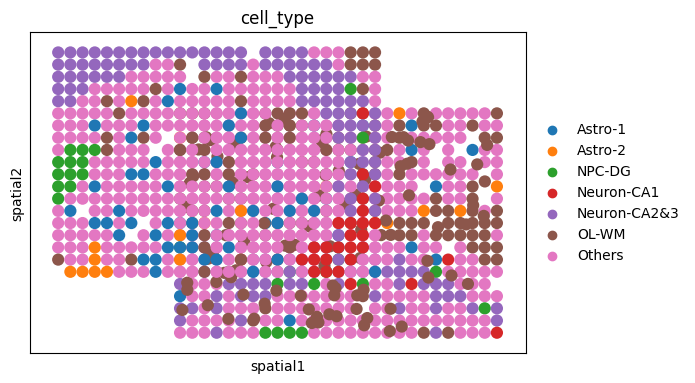

In [16]:
sc.pl.spatial(adata_perturb, color="cell_type", spot_size=1)

In [14]:
adata_injected_celltype = adata_perturb[adata_perturb.obs["injected"].notna()].copy()
adata_injected_celltype.obs["injected"] = adata_injected_celltype.obs["injected"].astype(bool)
adata_perturb_sub = adata_injected_celltype[~adata_injected_celltype.obs["injected"]].copy()
SLICE_OLD   = "Hippocampus_O_2_1"
SLICE_YOUNG = "Hippocampus_Y_2_1"

In [15]:
adata_perturb.obs["injected"]

61_11-Hippocampus_O_2_1    False
61_12-Hippocampus_O_2_1    False
61_13-Hippocampus_O_2_1    False
61_14-Hippocampus_O_2_1    False
61_15-Hippocampus_O_2_1    False
                           ...  
77_24-Hippocampus_Y_2_1     <NA>
77_6-Hippocampus_Y_2_1      <NA>
77_7-Hippocampus_Y_2_1      <NA>
77_8-Hippocampus_Y_2_1      <NA>
77_9-Hippocampus_Y_2_1      <NA>
Name: injected, Length: 976, dtype: boolean

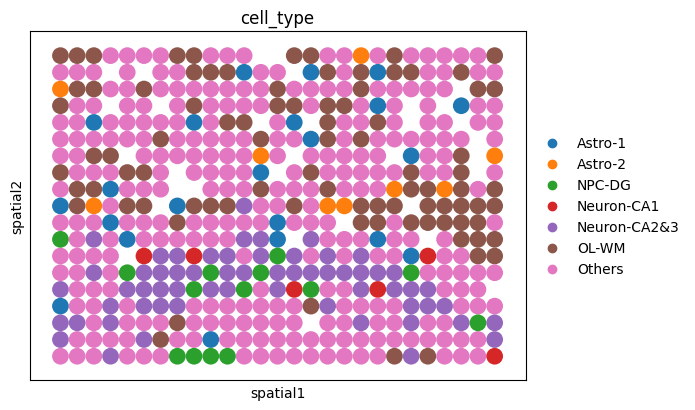

In [21]:
sc.pl.spatial(adata_injected_celltype, color="cell_type", spot_size=1)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, rbf_kernel
from scipy.stats import wasserstein_distance

def bootstrap_metric_distributions(
    adata_ori_result,
    adata_perturb_result,
    target_slice_young,
    target_slice_old,
    target_celltype=None,
    embedding_key="X_emb",
    metric="cosine",
    n_boot=500,
    sample_size=200,
    gamma=1.0,
    random_state=0,
    exclude_celltype=True,
):
    """
    生成三条分布 (Young vs Young, Old vs Young, Perturb vs Young)
    支持 metric: "cosine", "emd", "mmd"
    
    参数:
    - target_celltype: 指定 celltype，如果 exclude_celltype=True 时会排除该类型
    - exclude_celltype: 是否排除目标 celltype（默认为 True），
                        False 时表示不区分 celltype，直接用所有 cell
    """

    rng = np.random.default_rng(random_state)

    def filter_cells(adata, slice_name, exclude=False):
        if exclude and target_celltype is not None:
            return np.asarray(
                adata.obsm[embedding_key][
                    (adata.obs["slice"] == slice_name) &
                    (adata.obs["cell_type"] != target_celltype)
                ]
            )
        else:
            return np.asarray(
                adata.obsm[embedding_key][
                    (adata.obs["slice"] == slice_name)
                ]
            )

    # --- 取 embedding ---
    emb_young   = filter_cells(adata_ori_result, target_slice_young, exclude=exclude_celltype)
    emb_old     = filter_cells(adata_ori_result, target_slice_old,   exclude=exclude_celltype)
    emb_perturb = filter_cells(adata_perturb_result, target_slice_old, exclude=exclude_celltype)

    # NaN 处理
    emb_young   = np.nan_to_num(emb_young, nan=0.0)
    emb_old     = np.nan_to_num(emb_old, nan=0.0)
    emb_perturb = np.nan_to_num(emb_perturb, nan=0.0)

    # 定义指标函数
    def cosine_to_mean(X, Y):
        xbar = X.mean(axis=0, keepdims=True)
        ybar = Y.mean(axis=0, keepdims=True)
        return float(cosine_similarity(xbar, ybar)[0,0])

    def emd_avg_1d(X, Y):
        d = X.shape[1]
        return float(np.mean([wasserstein_distance(X[:,i], Y[:,i]) for i in range(d)]))

    def mmd_rbf(X, Y, gamma=1.0):
        Kxx = rbf_kernel(X, X, gamma=gamma).mean()
        Kyy = rbf_kernel(Y, Y, gamma=gamma).mean()
        Kxy = rbf_kernel(X, Y, gamma=gamma).mean()
        return float(Kxx + Kyy - 2*Kxy)

    if metric == "cosine":
        metric_fn = cosine_to_mean
    elif metric == "emd":
        metric_fn = emd_avg_1d
    elif metric == "mmd":
        metric_fn = lambda X,Y: mmd_rbf(X,Y,gamma=gamma)
    else:
        raise ValueError("metric 必须是 'cosine', 'emd', 或 'mmd'")

    # --- bootstrap ---
    def resample(X, n):
        idx = rng.choice(X.shape[0], size=n, replace=True)
        return X[idx]

    yy, oy, py = [], [], []
    mY = min(emb_young.shape[0], sample_size)
    mO = min(emb_old.shape[0], sample_size)
    mP = min(emb_perturb.shape[0], sample_size)

    for _ in range(n_boot):
        Y1, Y2 = resample(emb_young, mY), resample(emb_young, mY)
        yy.append(metric_fn(Y1, Y2))

        O, Yb = resample(emb_old, mO), resample(emb_young, mY)
        oy.append(metric_fn(O, Yb))

        P, Yc = resample(emb_perturb, mP), resample(emb_young, mY)
        py.append(metric_fn(P, Yc))

    return np.array(yy), np.array(oy), np.array(py)


def plot_three_distributions(yvsy, ovsy, pvsy, title, bins=10):
    """画三条分布的直方图 + 均值竖线"""
    fig, ax = plt.subplots(figsize=(8,4.8))

    ax.hist(yvsy, bins=bins, density=True, alpha=0.4, label="Young vs Young")
    ax.hist(ovsy, bins=bins, density=True, alpha=0.4, label="Old vs Young")
    ax.hist(pvsy, bins=bins, density=True, alpha=0.4, label="Perturb vs Young")

    ax.axvline(np.mean(yvsy), linestyle="--", linewidth=1.2, label=f"YvY mean={np.mean(yvsy):.3f}")
    ax.axvline(np.mean(ovsy), linestyle="--", linewidth=1.2, label=f"OvY mean={np.mean(ovsy):.3f}")
    ax.axvline(np.mean(pvsy), linestyle="--", linewidth=1.2, label=f"PvY mean={np.mean(pvsy):.3f}")

    ax.set_title(title)
    ax.set_xlabel("Metric value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    plt.tight_layout()
    # plt.savefig(os.path.join(out_fig_dir,"EMD_plot.pdf"), bbox_inches="tight")
    plt.show()

In [17]:
result = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_sub,
    target_slice_young=SLICE_YOUNG,
    target_slice_old=SLICE_OLD,
    target_celltype="NPC-DG",
    embedding_key="X_emb"
)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

def plot_cosine_to_centroids_non_target(
    adata_ori,
    adata_perturb,
    slice_young,
    slice_old,
    target_cell,
    celltype_key="cell_type",
    emb_key="X_emb",
    title="Cell state positioning (non-target cells only)",
    save_path=None
):
    """
    绘制非 target 细胞的余弦相似度散点图。
    target_cell 在所有计算和绘制中都被完全排除。
    """

    # ====== 取 embedding ======
    X_ori = adata_ori.obsm[emb_key]
    if hasattr(X_ori, "toarray"):
        X_ori = X_ori.toarray()
    X_perturb = adata_perturb.obsm[emb_key]
    if hasattr(X_perturb, "toarray"):
        X_perturb = X_perturb.toarray()

    # ====== 构造非 target 的 mask ======
    ct_ori = adata_ori.obs[celltype_key].astype(str).values
    ct_perturb = adata_perturb.obs[celltype_key].astype(str).values

    young_mask = (adata_ori.obs["slice"].astype(str) == slice_young) & (ct_ori != target_cell)
    old_mask   = (adata_ori.obs["slice"].astype(str) == slice_old) & (ct_ori != target_cell)
    pert_mask  = (adata_perturb.obs["slice"].astype(str) == slice_old) & (ct_perturb != target_cell)

    print(f"[INFO] Excluding target cell type: {target_cell}")
    print(f"[INFO] Remaining cells - Young: {young_mask.sum()}, Old: {old_mask.sum()}, Perturb: {pert_mask.sum()}")

    # ====== 计算质心 ======
    X_unit_ori = normalize(X_ori, norm="l2", axis=1)
    young_centroid = normalize(X_unit_ori[young_mask].mean(axis=0, keepdims=True), norm="l2", axis=1)[0]
    old_centroid   = normalize(X_unit_ori[old_mask].mean(axis=0, keepdims=True),   norm="l2", axis=1)[0]

    def cos_coords(X):
        X_unit = normalize(X, norm="l2", axis=1)
        cos_y = X_unit @ young_centroid
        cos_o = X_unit @ old_centroid
        return cos_y, cos_o

    cos_y_y, cos_o_y = cos_coords(X_ori[young_mask])
    cos_y_o, cos_o_o = cos_coords(X_ori[old_mask])
    cos_y_p, cos_o_p = cos_coords(X_perturb[pert_mask])

    # ====== 作图 ======
    plt.figure(figsize=(6.5, 6))

    plt.scatter(cos_y_y, cos_o_y, s=35, c="#076a3a", alpha=0.7, edgecolor="none", label="Young cells")
    plt.scatter(cos_y_o, cos_o_o, s=35, c="#073f6a", alpha=0.7, edgecolor="none", label="Old cells")
    plt.scatter(cos_y_p, cos_o_p, s=35, c="#791f1f", alpha=0.8, edgecolor="none", label="Perturb cells")

    # 各组均值点（星型标记）
    plt.scatter(np.mean(cos_y_y), np.mean(cos_o_y), c="#076a3a", s=200, marker="*", edgecolor="white", linewidth=1, label="Young mean")
    plt.scatter(np.mean(cos_y_o), np.mean(cos_o_o), c="#073f6a", s=200, marker="*", edgecolor="white", linewidth=1, label="Old mean")
    plt.scatter(np.mean(cos_y_p), np.mean(cos_o_p), c="#791f1f", s=200, marker="*", edgecolor="white", linewidth=1, label="Perturb mean")

    # 对角线 & 坐标设置
    all_cos = np.concatenate([cos_y_y, cos_o_y, cos_y_o, cos_o_o, cos_y_p, cos_o_p])
    lim_min, lim_max = all_cos.min(), all_cos.max()
    pad = 0.02
    plt.plot([lim_min-pad, lim_max+pad], [lim_min-pad, lim_max+pad], ls="--", c="gray", lw=1)
    plt.xlim(lim_min-pad, lim_max+pad)
    plt.ylim(lim_min-pad, lim_max+pad)

    plt.xlabel("Cosine similarity to young centroid")
    plt.ylabel("Cosine similarity to old centroid")
    plt.title(title)
    plt.legend()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(alpha=0.2, ls="--")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()

In [20]:
adata_perturb_sub.obs["injected"]

61_11-Hippocampus_O_2_1    False
61_12-Hippocampus_O_2_1    False
61_13-Hippocampus_O_2_1    False
61_14-Hippocampus_O_2_1    False
61_15-Hippocampus_O_2_1    False
                           ...  
87_24-Hippocampus_O_2_1    False
87_26-Hippocampus_O_2_1    False
87_27-Hippocampus_O_2_1    False
87_28-Hippocampus_O_2_1    False
87_29-Hippocampus_O_2_1    False
Name: injected, Length: 467, dtype: bool

[INFO] Excluding target cell type: NPC-DG
[INFO] Remaining cells - Young: 481, Old: 467, Perturb: 467


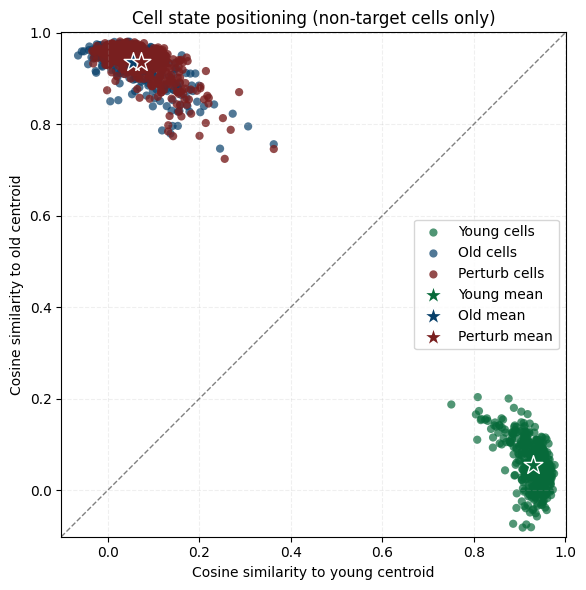

In [19]:
plot_cosine_to_centroids_non_target(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_sub,
    slice_young=SLICE_YOUNG,
    slice_old=SLICE_OLD,    # 你的 Old slice 名称
    target_cell="NPC-DG",
    emb_key="X_emb",
    # save_path="cosine_scatter_theory.pdf"
)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

def plot_celltype_cosine_to_young(
    adata_ori,
    adata_perturb,
    slice_young,
    slice_old,
    celltype_key="cell_type",
    emb_key="X_emb",
    save_path=None
):
    """
    绘制每个 celltype 扰动前/后的 Cosine to Young centroid 柱状图（带数值）
    自动去掉 celltype == 'other' / 'Others'
    """

    # ====== 取 embedding ======
    X_ori = adata_ori.obsm[emb_key]
    if hasattr(X_ori, "toarray"):
        X_ori = X_ori.toarray()
    X_perturb = adata_perturb.obsm[emb_key]
    if hasattr(X_perturb, "toarray"):
        X_perturb = X_perturb.toarray()

    sl_ori = adata_ori.obs["slice"].astype(str).values
    young_mask = sl_ori == slice_young
    old_mask   = sl_ori == slice_old

    sl_perturb = adata_perturb.obs["slice"].astype(str).values
    pert_mask = sl_perturb == slice_old

    # ====== 计算 Young 质心 ======
    X_unit_ori = normalize(X_ori, norm="l2", axis=1)
    young_centroid = normalize(
        X_unit_ori[young_mask].mean(axis=0, keepdims=True), norm="l2", axis=1
    )[0]

    def cos_to_young(X):
        X_unit = normalize(X, norm="l2", axis=1)
        return X_unit @ young_centroid

    # ====== 计算扰动前/后 (Old slice only) ======
    cos_y_before = cos_to_young(X_ori[old_mask])
    cos_y_after  = cos_to_young(X_perturb[pert_mask])

    ct_before = adata_ori.obs[celltype_key].values[old_mask]
    ct_after  = adata_perturb.obs[celltype_key].values[pert_mask]

    df_before = pd.DataFrame({"celltype": ct_before, "cos_y": cos_y_before, "status": "Before"})
    df_after  = pd.DataFrame({"celltype": ct_after,  "cos_y": cos_y_after,  "status": "After"})
    df_all = pd.concat([df_before, df_after], ignore_index=True)

    # ====== 去掉 other / Others ======
    df_all = df_all[~df_all["celltype"].str.lower().isin(["other","others"])]

    # ====== 按 celltype 聚合均值 ======
    df_mean = df_all.groupby(["celltype", "status"])["cos_y"].mean().reset_index()
    celltypes = df_mean["celltype"].unique()

    # ====== 画柱状图 ======
    x = np.arange(len(celltypes))
    width = 0.35
    colors = {"Before": "#073f6aff", "After": "#791f1fff"}

    plt.figure(figsize=(10, 5))
    for j, status in enumerate(["Before", "After"]):
        vals = df_mean[df_mean["status"]==status]["cos_y"].values
        bars = plt.bar(x + (j-0.5)*width, vals, width, label=status, color=colors[status])
        for bar, val in zip(bars, vals):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    plt.xticks(x, celltypes, rotation=45, ha="right")
    plt.ylabel("Cosine similarity to Young centroid")
    plt.title("Celltype mean cosine similarity (Before vs After perturbation)")
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()

In [21]:
import numpy as np
import pandas as pd

def analyze_inject_gene_reconstruction_change(
    adata_ori_result,
    adata_perturb_result,
    target_cell=None,             # ✅ 新增：要排除的 celltype
    target_obs_names=None,
    filter_by=None,
    top_n=100,
    sort_abs=True,
    recon_key="X_pred",
    celltype_key="cell_type"      # ✅ 可指定 cell_type 字段名
):
    """
    Compare reconstructed gene expression between original and perturbed AnnData objects,
    excluding a specific target cell type if provided.
    """

    # ===== Step 0: 排除 target cell =====
    if target_cell is not None:
        mask_ori = adata_ori_result.obs[celltype_key] != target_cell
        mask_perturb = adata_perturb_result.obs[celltype_key] != target_cell
        adata_ori_result = adata_ori_result[mask_ori].copy()
        adata_perturb_result = adata_perturb_result[mask_perturb].copy()
        print(f"[INFO] Excluding target cell type: {target_cell}")
        print(f"[INFO] Remaining cells: {adata_ori_result.n_obs} (ori), {adata_perturb_result.n_obs} (perturb)")

    # ===== Step 1: Select target obs_names =====
    if target_obs_names is not None:
        selected_obs_names = pd.Index(target_obs_names)
    elif filter_by is not None:
        mask = np.ones(len(adata_perturb_result), dtype=bool)
        for key, val in filter_by.items():
            mask &= (adata_perturb_result.obs[key] == val).values
        selected_obs_names = adata_perturb_result.obs_names[mask]
    else:
        raise ValueError("You must specify either `target_obs_names` or `filter_by`.")

    # ===== Step 2: Ensure intersection =====
    selected_obs_names = selected_obs_names[
        selected_obs_names.isin(adata_ori_result.obs_names) &
        selected_obs_names.isin(adata_perturb_result.obs_names)
    ]

    if len(selected_obs_names) == 0:
        raise ValueError("No matching obs_names found in both adatas after filtering.")

    # ===== Step 3: Get reconstructed expression =====
    obs_idx = adata_ori_result.obs_names.get_indexer(selected_obs_names)
    X_ori = adata_ori_result.obsm[recon_key][obs_idx]
    X_perturb = adata_perturb_result.obsm[recon_key][obs_idx]

    # ===== Step 4: Compute gene-wise mean and delta =====
    mean_ori = X_ori.mean(axis=0)
    mean_perturb = X_perturb.mean(axis=0)
    delta = mean_perturb - mean_ori

    # ===== Step 5: Construct DataFrame =====
    df = pd.DataFrame({
        "gene_id": adata_ori_result.var_names,
        "gene_symbol": adata_ori_result.var["gene_symbol"].values,
        "ori_mean_expr": mean_ori,
        "perturb_mean_expr": mean_perturb,
        "delta_expr": delta,
        "abs_delta": np.abs(delta)
    })

    df_sorted = df.sort_values("abs_delta", ascending=False).head(top_n) if sort_abs \
        else df.sort_values("delta_expr", ascending=False).head(top_n)

    return df_sorted

[INFO] Excluding target cell type: NPC-DG
[INFO] Remaining cells: 948 (ori), 467 (perturb)
                  gene_id gene_symbol  ori_mean_expr  perturb_mean_expr  \
4829   ENSMUSG00000060962        Dmkn       0.736658           0.732545   
13161  ENSMUSG00000053310        Nrgn       0.547484           0.550133   
16940  ENSMUSG00000023886       Smoc2       0.263342           0.261704   
14642  ENSMUSG00000021948       Prkcd       0.327670           0.326094   
2546   ENSMUSG00000008999        Bmp7       0.270211           0.268639   
10587  ENSMUSG00000001504        Irx2       0.232861           0.231356   
9538   ENSMUSG00000031517       Gpm6a       0.425745           0.427226   
11551  ENSMUSG00000022587        Ly6e       0.479542           0.480932   
11471  ENSMUSG00000022759     Lrrc74b       0.169947           0.168582   
2999   ENSMUSG00000036598     Ccdc113       0.195479           0.194114   

       delta_expr  abs_delta  
4829    -0.004112   0.004112  
13161    0.002649   0

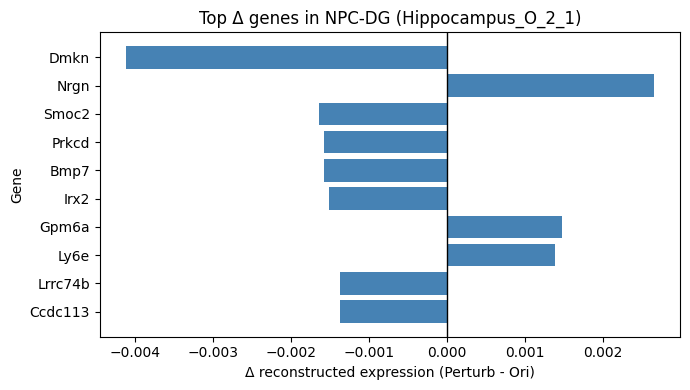

In [22]:
# ===== 选择一个 celltype 来分析 =====
target_celltype = "NPC-DG"   # 举例
target_slice = SLICE_OLD    # 只看 Old slice 的这个 celltype

# 调用函数
df_delta = analyze_inject_gene_reconstruction_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_sub,
    target_cell="NPC-DG",       # ✅ 不参与分析的细胞类型
    filter_by={"slice": target_slice},  # 例如选定老样本
    top_n=10
)

# 打印结果
print(df_delta)

# ===== 可视化（条形图） =====
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.barh(df_delta["gene_symbol"], df_delta["delta_expr"], color="steelblue")
plt.axvline(0, color="black", lw=1)
plt.xlabel("Δ reconstructed expression (Perturb - Ori)")
plt.ylabel("Gene")
plt.title(f"Top Δ genes in {target_celltype} ({target_slice})")
plt.gca().invert_yaxis()  # 让 top 基因在上方
plt.tight_layout()
plt.show()

2025-10-19 10:46:54,765 INFO maxp pruned
2025-10-19 10:46:54,774 INFO cmap pruned
2025-10-19 10:46:54,775 INFO kern dropped
2025-10-19 10:46:54,776 INFO post pruned
2025-10-19 10:46:54,777 INFO FFTM dropped
2025-10-19 10:46:54,779 INFO GPOS pruned
2025-10-19 10:46:54,783 INFO GSUB pruned
2025-10-19 10:46:54,790 INFO glyf pruned
2025-10-19 10:46:54,791 INFO Added gid0 to subset
2025-10-19 10:46:54,792 INFO Added first four glyphs to subset
2025-10-19 10:46:54,793 INFO Closing glyph list over 'MATH': 48 glyphs before
2025-10-19 10:46:54,794 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'G', 'I', 'L', 'N', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'y', 'zero']
2025-10-19 10:46:54,795 INFO Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 36, 37, 38, 39, 42, 44, 

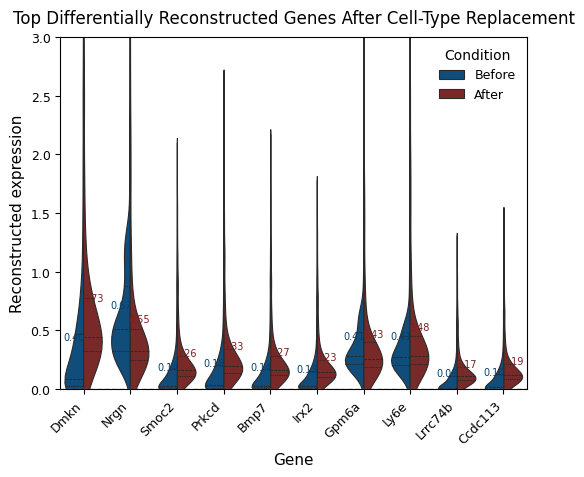

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# ===== 基因排序：按 Delta 从大到小，取前20 =====
top_genes = (
    df_delta.sort_values("abs_delta", ascending=False)
    .head(20)["gene_symbol"].tolist()
)

# 提取原始和扰动后的表达矩阵
X_ori = adata_ori.obsm["X_pred"]
X_perturb = adata_perturb_sub.obsm["X_pred"]

# 只选取 top 基因索引
gene_idx = adata_ori.var["gene_symbol"].isin(top_genes)

expr_ori = X_ori[:, gene_idx]
expr_perturb = X_perturb[:, gene_idx]

# 构建 DataFrame
df_plot = pd.DataFrame(expr_ori, columns=adata_ori.var["gene_symbol"][gene_idx])
df_plot = df_plot.melt(var_name="gene_symbol", value_name="expr")
df_plot["condition"] = "Before"

df_plot2 = pd.DataFrame(expr_perturb, columns=adata_ori.var["gene_symbol"][gene_idx])
df_plot2 = df_plot2.melt(var_name="gene_symbol", value_name="expr")
df_plot2["condition"] = "After"

df_plot = pd.concat([df_plot, df_plot2], ignore_index=True)

# 保证顺序：按 Δ 排
df_plot["gene_symbol"] = pd.Categorical(df_plot["gene_symbol"], categories=top_genes, ordered=True)

# ===== 绘制小提琴图 =====
plt.figure(figsize=(5.5, 4.8))  # ✅ x 轴更紧凑
sns.violinplot(
    data=df_plot,
    x="gene_symbol", y="expr", hue="condition",
    split=True, inner="quartile",
    palette={"Before": "#004f8bff", "After": "#871b1bff"},
    linewidth=0.8, scale="width"  # ✅ 更均匀的宽度
)

# 标注均值
means = df_plot.groupby(["gene_symbol", "condition"])["expr"].mean().reset_index()
for i, gene in enumerate(top_genes):
    for cond, color in zip(["Before", "After"], ["#073f6aff", "#791f1fff"]):
        mean_val = means.query("gene_symbol==@gene and condition==@cond")["expr"].values[0]
        x_offset = -0.2 if cond == "Before" else 0.2
        plt.text(i + x_offset, mean_val, f"{mean_val:.2f}", color=color,
                 ha="center", va="bottom", fontsize=7)

# ===== 坐标 & 样式优化 =====
plt.ylim(0, 3)                   # ✅ 固定 y 轴范围到 3
plt.axhline(0, ls="--", c="gray", lw=1)
plt.xlabel("Gene", fontsize=11)
plt.ylabel("Reconstructed expression", fontsize=11)
plt.title("Top Differentially Reconstructed Genes After Cell-Type Replacement", fontsize=12, pad=10)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.legend(title="Condition", fontsize=9, title_fontsize=10, frameon=False)

plt.tight_layout(pad=0.8, rect=[0.02, 0, 1, 1])  # ✅ 收紧 x 轴和整体边距
# plt.show()
plt.savefig("violin_rec_exp_by_injected_theory2.pdf", bbox_inches="tight", dpi=300)

In [32]:
aging_genes = {
    "Bc1","Tlk1","Meg3","Ppm1e","Tmsb4x","Stmn3","Rtn1",
    "Prkca","Snhg11","Fth1"
}


568


Found aging genes: ['Stmn3', 'Tmsb4x', 'Meg3', 'Rtn1', 'Snhg11', 'Fth1', 'Prkca', 'Bc1', 'Ppm1e', 'Tlk1']


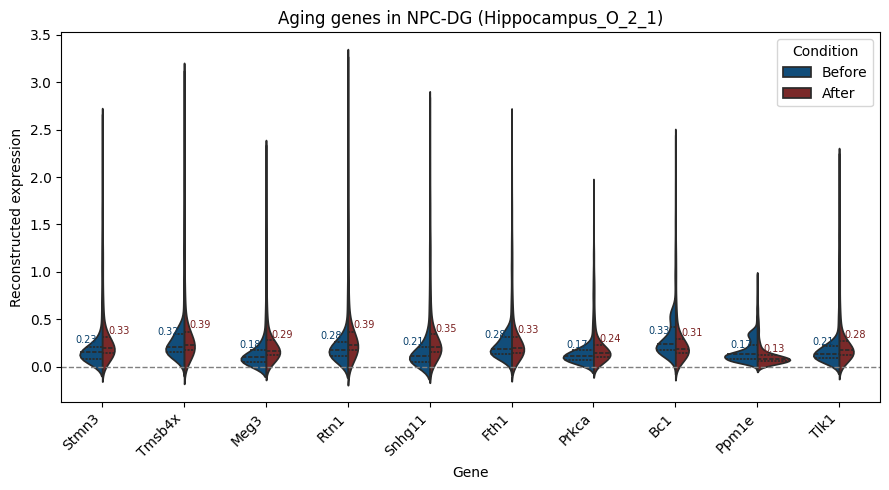

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==== Aging gene set ====
aging_genes = {
    "Bc1","Tlk1","Meg3","Ppm1e","Tmsb4x","Stmn3","Rtn1",
    "Prkca","Snhg11","Fth1"
}

# 只保留在数据里存在的基因
aging_genes_in_data = [g for g in aging_genes if g in adata_ori.var["gene_symbol"].values]
print("Found aging genes:", aging_genes_in_data)

# ==== 提取原始和扰动后的表达 ====
X_ori = adata_ori.obsm["X_pred"]
X_perturb = adata_perturb_sub.obsm["X_pred"]

# 只选 aging gene
gene_idx = adata_ori.var["gene_symbol"].isin(aging_genes_in_data)

expr_ori = X_ori[:, gene_idx]
expr_perturb = X_perturb[:, gene_idx]

# ==== 构建 DataFrame ====
df_plot = pd.DataFrame(expr_ori, columns=adata_ori.var["gene_symbol"][gene_idx])
df_plot = df_plot.melt(var_name="gene_symbol", value_name="expr")
df_plot["condition"] = "Before"

df_plot2 = pd.DataFrame(expr_perturb, columns=adata_ori.var["gene_symbol"][gene_idx])
df_plot2 = df_plot2.melt(var_name="gene_symbol", value_name="expr")
df_plot2["condition"] = "After"

df_plot = pd.concat([df_plot, df_plot2], ignore_index=True)

# 保证顺序：按照 aging_genes_in_data 顺序
df_plot["gene_symbol"] = pd.Categorical(df_plot["gene_symbol"], categories=aging_genes_in_data, ordered=True)

# ==== 绘制 violin plot ====
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=df_plot,
    x="gene_symbol", y="expr", hue="condition",
    split=True, inner="quartile",
    palette={"Before": "#004f8bff", "After": "#871b1bff"}
)

# 标注均值
means = df_plot.groupby(["gene_symbol", "condition"])["expr"].mean().reset_index()
for i, gene in enumerate(aging_genes_in_data):
    for cond, color in zip(["Before", "After"], ["#073f6aff", "#791f1fff"]):
        mean_val = means.query("gene_symbol==@gene and condition==@cond")["expr"].values[0]
        x_offset = -0.2 if cond=="Before" else 0.2
        plt.text(i + x_offset, mean_val, f"{mean_val:.2f}", color=color,
                 ha="center", va="bottom", fontsize=7)

plt.axhline(0, ls="--", c="gray", lw=1)
plt.xlabel("Gene")
plt.ylabel("Reconstructed expression")
plt.title(f"Aging genes in {target_celltype} ({target_slice})")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

Found aging genes: ['Stmn3', 'Tmsb4x', 'Meg3', 'Rtn1', 'Snhg11', 'Fth1', 'Prkca', 'Bc1', 'Ppm1e', 'Tlk1']


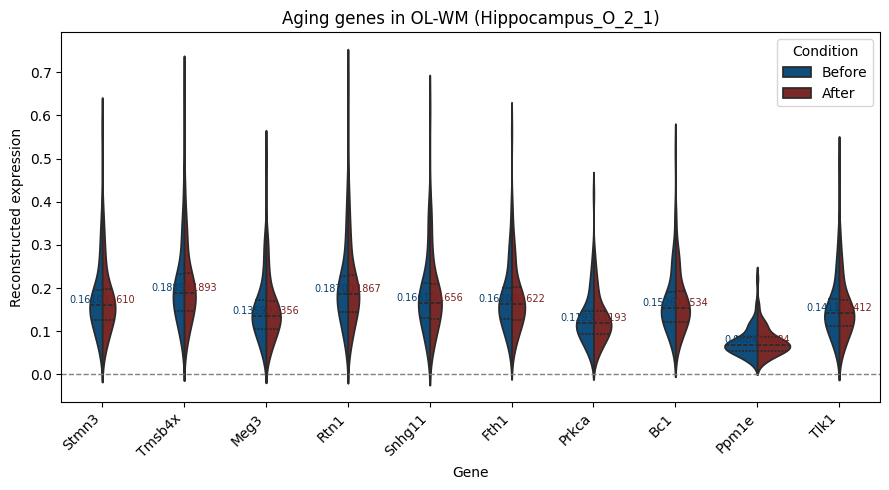

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==== Aging gene set ====
aging_genes = {
    "Bc1","Tlk1","Meg3","Ppm1e","Tmsb4x","Stmn3","Rtn1",
    "Prkca","Snhg11","Fth1"
}

# ==== 指定 celltype ====
target_celltype = "OL-WM"
target_slice = "Hippocampus_O_2_1"   # 举例，也可以只限制 celltype

mask_ori = (adata_ori.obs["cell_type"] == target_celltype) & (adata_ori.obs["slice"] == target_slice)
mask_pert = (adata_perturb_sub.obs["cell_type"] == target_celltype) & (adata_perturb_sub.obs["slice"] == target_slice)

# ==== Aging genes 过滤 ====
aging_genes_in_data = [g for g in aging_genes if g in adata_ori.var["gene_symbol"].values]
print("Found aging genes:", aging_genes_in_data)
gene_idx = adata_ori.var["gene_symbol"].isin(aging_genes_in_data)

# ==== 提取预测表达 (只看指定 celltype 的细胞) ====
X_ori = adata_ori.obsm["X_pred"][mask_ori][:, gene_idx]
X_perturb = adata_perturb_sub.obsm["X_pred"][mask_pert][:, gene_idx]

# ==== 构建 DataFrame ====
df_plot = pd.DataFrame(X_ori, columns=adata_ori.var["gene_symbol"][gene_idx])
df_plot = df_plot.melt(var_name="gene_symbol", value_name="expr")
df_plot["condition"] = "Before"

df_plot2 = pd.DataFrame(X_perturb, columns=adata_ori.var["gene_symbol"][gene_idx])
df_plot2 = df_plot2.melt(var_name="gene_symbol", value_name="expr")
df_plot2["condition"] = "After"

df_plot = pd.concat([df_plot, df_plot2], ignore_index=True)

# 保证基因顺序
df_plot["gene_symbol"] = pd.Categorical(df_plot["gene_symbol"], categories=aging_genes_in_data, ordered=True)

# ==== 绘制 violin plot ====
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=df_plot,
    x="gene_symbol", y="expr", hue="condition",
    split=True, inner="quartile",
    palette={"Before": "#004f8bff", "After": "#871b1bff"}
)

# 标注均值
means = df_plot.groupby(["gene_symbol", "condition"])["expr"].median().reset_index()
for i, gene in enumerate(aging_genes_in_data):
    for cond, color in zip(["Before", "After"], ["#073f6aff", "#791f1fff"]):
        mean_val = means.query("gene_symbol==@gene and condition==@cond")["expr"].values[0]
        x_offset = -0.2 if cond=="Before" else 0.2
        plt.text(i + x_offset, mean_val, f"{mean_val:.4f}", color=color,
                 ha="center", va="bottom", fontsize=7)

plt.axhline(0, ls="--", c="gray", lw=1)
plt.xlabel("Gene")
plt.ylabel("Reconstructed expression")
plt.title(f"Aging genes in {target_celltype} ({target_slice})")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Condition")
plt.tight_layout()
plt.show()

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

# ===== 运行富集分析 =====
enr = gp.enrichr(
    gene_list=top_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='Mouse',
    outdir=None,
    cutoff=0.05
)

# ===== 提取富集结果 =====
df = enr.results.copy()
df["Term_lower"] = df["Term"].str.lower()

In [113]:
df["Term_lower"][:15]

0               nervous system development (go:0007399)
1        regulation of filopodium assembly (go:0051489)
2     epithelial to mesenchymal transition (go:0001837)
3     plasma membrane bounded cell projection morpho...
4             plasma membrane organization (go:0007009)
5     positive regulation of cell differentiation (g...
6            regulation of gene expression (go:0010468)
7                pericardium morphogenesis (go:0003344)
8        l-ascorbic acid metabolic process (go:0019852)
9     regulation of blood vessel remodeling (go:0060...
10    regulation of plasma membrane repair (go:1905684)
11    negative regulation of cardiac muscle cell dif...
12    positive regulation of macromolecule biosynthe...
13    regulation of endodeoxyribonuclease activity (...
14    regulation of glial cell apoptotic process (go...
Name: Term_lower, dtype: object

In [114]:
df[:15]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Term_lower
0,GO_Biological_Process_2025,Nervous System Development (GO:0007399),5/480,0.000090,0.029875,0,0,13.687719,127.554057,GPM6A;OLFM1;SLC2A1;SOX6;NRGN,nervous system development (go:0007399)
1,GO_Biological_Process_2025,Regulation of Filopodium Assembly (GO:0051489),2/40,0.000724,0.067673,0,0,58.309942,421.597121,GPM6A;PRKCD,regulation of filopodium assembly (go:0051489)
2,GO_Biological_Process_2025,Epithelial to Mesenchymal Transition (GO:0001837),2/51,0.001176,0.067673,0,0,45.195011,304.861130,OLFM1;BMP7,epithelial to mesenchymal transition (go:0001837)
3,GO_Biological_Process_2025,Plasma Membrane Bounded Cell Projection Morpho...,2/54,0.001318,0.067673,0,0,42.581197,282.391215,GPM6A;BMP7,plasma membrane bounded cell projection morpho...
4,GO_Biological_Process_2025,Plasma Membrane Organization (GO:0007009),2/75,0.002523,0.067673,0,0,30.299848,181.257422,DMKN;SYTL4,plasma membrane organization (go:0007009)
5,GO_Biological_Process_2025,Positive Regulation of Cell Differentiation (G...,3/297,0.003064,0.067673,0,0,11.816327,68.391627,OLFM1;SOX6;BMP7,positive regulation of cell differentiation (g...
6,GO_Biological_Process_2025,Regulation of Gene Expression (GO:0010468),5/1127,0.004290,0.067673,0,0,5.602496,30.541744,OLFM1;ATP1B1;SOX6;BMP7;ST18,regulation of gene expression (go:0010468)
7,GO_Biological_Process_2025,Pericardium Morphogenesis (GO:0003344),1/5,0.004990,0.067673,0,0,262.842105,1393.123889,BMP7,pericardium morphogenesis (go:0003344)
8,GO_Biological_Process_2025,L-ascorbic Acid Metabolic Process (GO:0019852),1/5,0.004990,0.067673,0,0,262.842105,1393.123889,SLC2A1,l-ascorbic acid metabolic process (go:0019852)
9,GO_Biological_Process_2025,Regulation of Blood Vessel Remodeling (GO:0060...,1/5,0.004990,0.067673,0,0,262.842105,1393.123889,CST3,regulation of blood vessel remodeling (go:0060...


2025-09-17 08:20:20,983 INFO maxp pruned
2025-09-17 08:20:21,004 INFO cmap pruned
2025-09-17 08:20:21,005 INFO kern dropped
2025-09-17 08:20:21,006 INFO post pruned
2025-09-17 08:20:21,006 INFO FFTM dropped
2025-09-17 08:20:21,010 INFO GPOS pruned
2025-09-17 08:20:21,019 INFO GSUB pruned
2025-09-17 08:20:21,033 INFO glyf pruned
2025-09-17 08:20:21,035 INFO Added gid0 to subset
2025-09-17 08:20:21,035 INFO Added first four glyphs to subset
2025-09-17 08:20:21,036 INFO Closing glyph list over 'MATH': 51 glyphs before
2025-09-17 08:20:21,037 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'a', 'ampersand', 'b', 'c', 'd', 'e', 'f', 'four', 'g', 'h', 'i', 'j', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'two', 'u', 'v', 'w', 'x', 'y', 'zero']
2025-09-17 08:20:21,039 INFO Glyph IDs:   [0, 1, 2, 3, 9, 11, 12, 19, 20, 21, 23, 36, 37, 38, 39, 40, 41, 42, 47,

2025-09-17 08:20:21,041 INFO Closed glyph list over 'MATH': 57 glyphs after
2025-09-17 08:20:21,041 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'a', 'ampersand', 'b', 'c', 'd', 'e', 'f', 'four', 'g', 'h', 'i', 'j', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'two', 'u', 'uni239B', 'uni239C', 'uni239D', 'uni239E', 'uni239F', 'uni23A0', 'v', 'w', 'x', 'y', 'zero']
2025-09-17 08:20:21,043 INFO Glyph IDs:   [0, 1, 2, 3, 9, 11, 12, 19, 20, 21, 23, 36, 37, 38, 39, 40, 41, 42, 47, 48, 49, 50, 51, 53, 54, 55, 57, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 3228, 3506, 3507, 3508, 3509, 3510, 3511]
2025-09-17 08:20:21,043 INFO Closing glyph list over 'GSUB': 57 glyphs before
2025-09-17 08:20:21,044 INFO Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'L', 'M', 'N', 'O', 'P', 'R', 'S', '

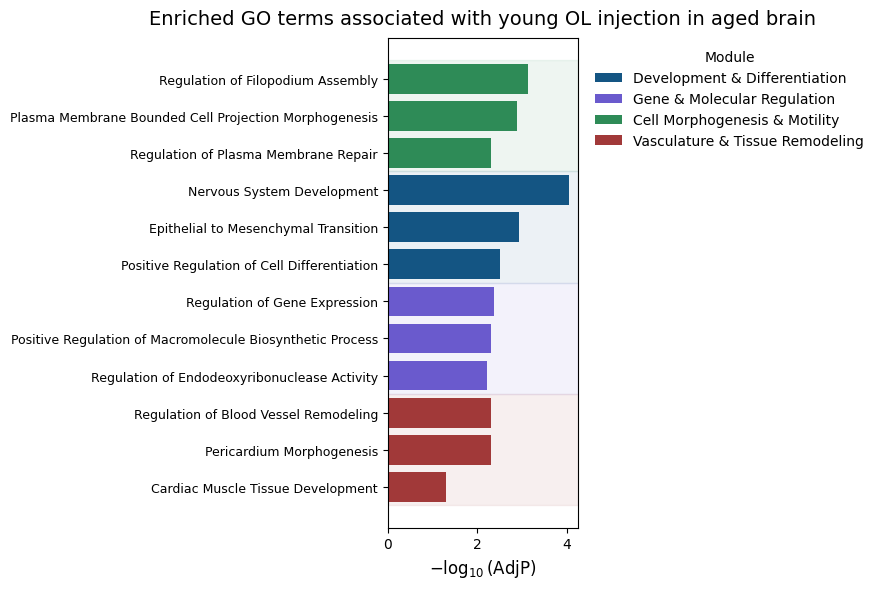

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ====== Step 1. 确保有小写列用于匹配 ======
df["Term_lower"] = df["Term"].str.lower()

# ====== Step 2. Context-specific GO term classification ======
go_keywords_from_injection = {
    # 1. Development & Differentiation
    "nervous system development": "Development & Differentiation",
    "epithelial to mesenchymal transition": "Development & Differentiation",
    "positive regulation of cell differentiation": "Development & Differentiation",

    # 2. Gene & Molecular Regulation
    "regulation of gene expression": "Gene & Molecular Regulation",
    "positive regulation of macromolecule biosynthetic process": "Gene & Molecular Regulation",
    "regulation of endodeoxyribonuclease activity": "Gene & Molecular Regulation",

    # 3. Cell Morphogenesis & Motility
    "plasma membrane bounded cell projection morphogenesis": "Cell Morphogenesis & Motility",
    "regulation of plasma membrane repair": "Cell Morphogenesis & Motility",
    "regulation of filopodium assembly": "Cell Morphogenesis & Motility",

    # 4. Vasculature & Tissue Remodeling
    "regulation of blood vessel remodeling": "Vasculature & Tissue Remodeling",
    "cardiac muscle tissue development": "Vasculature & Tissue Remodeling",
    "pericardium morphogenesis": "Vasculature & Tissue Remodeling",
}



# ====== Step 3. 匹配 df，筛选 adj p < 0.01 ======
# 去掉 GO 号后再小写，生成一个新列用于精确匹配
df["Term_noGO"] = df["Term"].str.replace(r" \(GO:\d+\)", "", regex=True)
df["Term_noGO_lower"] = df["Term_noGO"].str.lower()

matched_rows = []
for kw, module in go_keywords_from_injection.items():
    matched = df[df["Term_noGO_lower"] == kw]   # 精确匹配去掉 GO 号的小写名
    matched = matched[matched["P-value"] < 0.05]   # adj p cutoff
    if not matched.empty:
        best = matched.sort_values("P-value").head(1).copy()
        best["Matched_Term"] = kw
        best["Module"] = module
        matched_rows.append(best)

if not matched_rows:
    raise ValueError("No GO terms passed the filtering (<0.01)")

plot_df = pd.concat(matched_rows, ignore_index=True)
plot_df["-log10(P-value)"] = -np.log10(plot_df["P-value"])

# 去掉 GO 号（保留干净的 Term）
plot_df["Term_clean"] = plot_df["Term"].str.replace(r" \(GO:\d+\)", "", regex=True)

# ====== Step 4. 颜色配置 ======
module_colors = {
    "Development & Differentiation": "#145583",          # 蓝
    "Gene & Molecular Regulation": "#6A5ACD",            # 紫
    "Cell Morphogenesis & Motility": "#2E8B57",          # 绿
    "Vasculature & Tissue Remodeling": "#A13939",        # 红
}
bg_alpha = 0.08
module_bg = {
    k: (*tuple(int(v[i:i+2], 16)/255 for i in (1,3,5)), bg_alpha) 
    for k,v in module_colors.items()
}

# ====== Step 5. 排序 ======
plot_df = plot_df.sort_values(["Module", "-log10(P-value)"], ascending=[True, False]).reset_index(drop=True)

# ====== Step 6. 绘图 ======
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(9, 6))

y_positions = np.arange(len(plot_df))
labels = plot_df["Term_clean"].tolist()
values = plot_df["-log10(P-value)"].values
mods   = plot_df["Module"].tolist()

# 背景色块（每个 module 一个浅色背景）
start = 0
for i in range(1, len(mods)+1):
    if i == len(mods) or mods[i] != mods[i-1]:
        ax.axhspan(start-0.5, i-0.5, color=module_bg[mods[i-1]])
        start = i

# 条形图
bar_colors = [module_colors[m] for m in mods]
ax.barh(y_positions, values, color=bar_colors)

# 坐标轴与标题
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel(r"$-\log_{10}(\mathrm{AdjP})$", fontsize=12)
ax.set_title("Enriched GO terms associated with young OL injection in aged brain", fontsize=14, pad=10)
ax.invert_yaxis()

# 图例
handles = [Patch(facecolor=module_colors[m], label=m) for m in module_colors]
ax.legend(handles=handles, title="Module", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.savefig(f"{out_fig_dir}/GO_enrichment_injected_related_terms.pdf", bbox_inches="tight")
plt.show()

In [26]:
# ================== 主循环 ==================
all_results = []
# output_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp"
# ori_input_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_input.h5ad")
# adata_fov_OL = sc.read_h5ad(ori_input_adata_path)
def compute_delta_cosine(adata_ori, adata_perturb, slice_young, slice_old, emb_key="X_emb", celltype_key="cell_type"):
    """
    计算 ΔCosine (Perturb vs Baseline)，返回 DataFrame
    """
    # ---- baseline embedding ----
    X_ori = adata_ori.obsm[emb_key]
    if hasattr(X_ori, "toarray"):
        X_ori = X_ori.toarray()

    sl_ori = adata_ori.obs["slice"].astype(str).values
    young_mask = sl_ori == slice_young
    old_mask   = sl_ori == slice_old

    # normalize
    X_unit_ori = normalize(X_ori, norm="l2", axis=1)
    young_centroid = normalize(X_unit_ori[young_mask].mean(axis=0, keepdims=True), norm="l2", axis=1)[0]

    def cos_to_young(X):
        X_unit = normalize(X, norm="l2", axis=1)
        return X_unit @ young_centroid

    cos_y_old_baseline = cos_to_young(X_ori[old_mask])
    ct_old_baseline = adata_ori.obs[celltype_key].values[old_mask]

    # ---- perturb embedding ----
    Xp = adata_perturb.obsm[emb_key]
    if hasattr(Xp, "toarray"):
        Xp = Xp.toarray()
    sl_p = adata_perturb.obs["slice"].astype(str).values
    pert_mask = sl_p == slice_old

    cos_y_after = cos_to_young(Xp[pert_mask])
    ct_after = adata_perturb.obs[celltype_key].values[pert_mask]

    # ---- ΔCosine per cell ----
    recs = []
    for ctype in np.unique(ct_after):
        if ctype.lower() in ["other", "others"]:
            continue
        vals_after = cos_y_after[ct_after == ctype]
        vals_base  = cos_y_old_baseline[ct_old_baseline == ctype]
        if len(vals_after)==0 or len(vals_base)==0:
            continue
        base_mean = np.mean(vals_base)
        for v in vals_after - base_mean:
            recs.append({"perturb_injected": ctype, "celltype": ctype, "delta_cos": v})

    return pd.DataFrame(recs)

for ct in list(adata_fov_OL.obs["cell_type"].unique()) + [None]:
    if ct == "Others":
        continue
    print(f"Injecting {ct}...")

    # old slice
    old_slice  = adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_O_2_1"]
    # donor
    young_pool = adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_Y_2_1"]

    # ===== 不同注入数量循环 =====
    for n_inject in range(10, 201, 10):
        print(f"  Inject {n_inject} cells...")

        # inject
        perturbed_adata = inject_cells_randomly(
            target_adata = old_slice,
            donor_adata  = young_pool,
            celltype     = ct,
            spatial_key  = "spatial",
            n_inject=n_inject,
            random_state=42
        )

        pert_input = ad.concat(
            [perturbed_adata, adata_fov_OL[adata_fov_OL.obs["slice"] == "Hippocampus_Y_2_1"]],
            join="outer"
        )

        output_prefix_perturb = f"inject_young_OL-WM_to_old_{ct}_n{n_inject}"
        perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
        pert_input.write(perturb_input_adata_path)
        print(f"Injected input adata saved to: {perturb_input_adata_path}")

        # run bbcellformer 推理
        adata_perturb_alltype = run_bbcellformer_pipeline(
            adata_path=perturb_input_adata_path,
            specie=specie,
            assay=assay,
            gene_dict_path=gene_dict_path,
            gene_mean_path=gene_mean_path,
            bb_ckpt_path=bb_ckpt_path,
            cellplm_ckpt_path=cellplm_ckpt_path,
            output_dir=output_dir,
            output_prefix=output_prefix_perturb,
            config_train=config_train,
            n_hvg=n_hvg,
            cd_weight=cd_weight,
            use_hvg=use_hvg,
            use_batch=False,
            use_spatial=True,
            weight_mode="expression",
            force_tokenize=True,
            do_fit=False,
            fit_epochs=10,
            device=device
        )

        # sub 非 injected
        adata_injected_celltype = adata_perturb_alltype[adata_perturb_alltype.obs["injected"].notna()].copy()
        adata_injected_celltype.obs["injected"] = adata_injected_celltype.obs["injected"].astype(bool)
        adata_perturb_sub = adata_injected_celltype[~adata_injected_celltype.obs["injected"]].copy()

        # compute ΔCosine
        df_delta = compute_delta_cosine(
            adata_ori=adata_ori,
            adata_perturb=adata_perturb_sub,
            slice_young=SLICE_YOUNG,
            slice_old=SLICE_OLD,
            emb_key="X_emb",
            celltype_key="cell_type"
        )
        df_delta["inject_ct"] = ct
        df_delta["n_inject"] = n_inject  # 记录注入数量
        all_results.append(df_delta)

# 合并结果
df_all_inject_num = pd.concat(all_results, ignore_index=True)
df_all_inject_num.to_csv(os.path.join(out_fig_dir, "delta_cosine_all_injections_and_num_step10.csv"), index=False)

... storing 'cell_type' as categorical
... storing 'injected_celltype' as categorical


Injecting OL-WM...
  Inject 10 cells...


Injected input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM_to_old_OL-WM_n10_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM_to_old_OL-WM_n10_input.h5ad
before quality control adata shape: (986, 20318)
After HVG (5000) selection: (986, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  1.95it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM_to_old_OL-WM_n10_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 986
Preprocessing time: 0.05 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


...

Injected input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM_to_old_None_n200_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
config_train['batch_size'] 64
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM_to_old_None_n200_input.h5ad
before quality control adata shape: (1176, 20318)
After HVG (5000) selection: (1176, 5000)
Computing cell density...


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  1.56it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM_to_old_None_n200_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 1176
Preprocessing time: 0.06 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 19/19 [00:29<00:00,  1.58s/it]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM_to_old_None_n200_bb_embeddings.npz
Time cost:  0.5936038335164388
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM_to_old_None_n200_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 genes remain.
Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/n2c_tmp/inject_young_OL-WM

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==== 读取结果 ====
csv_path = os.path.join(out_fig_dir, "delta_cosine_all_injections_and_num_step10.csv")
df_all = pd.read_csv(csv_path)

print("Data loaded:", df_all.shape)
print(df_all.head())

Data loaded: (27860, 5)
  perturb_injected celltype  delta_cos inject_ct  n_inject
0          Astro-1  Astro-1   0.032278     OL-WM        10
1          Astro-1  Astro-1  -0.072787     OL-WM        10
2          Astro-1  Astro-1  -0.057078     OL-WM        10
3          Astro-1  Astro-1   0.116605     OL-WM        10
4          Astro-1  Astro-1   0.101837     OL-WM        10


2025-09-23 10:29:43,119 INFO maxp pruned
2025-09-23 10:29:43,131 INFO cmap pruned
2025-09-23 10:29:43,139 INFO kern dropped
2025-09-23 10:29:43,140 INFO post pruned
2025-09-23 10:29:43,143 INFO FFTM dropped
2025-09-23 10:29:43,146 INFO GPOS pruned
2025-09-23 10:29:43,150 INFO GSUB pruned
2025-09-23 10:29:43,159 INFO glyf pruned
2025-09-23 10:29:43,161 INFO Added gid0 to subset
2025-09-23 10:29:43,161 INFO Added first four glyphs to subset
2025-09-23 10:29:43,162 INFO Closing glyph list over 'MATH': 47 glyphs before
2025-09-23 10:29:43,163 INFO Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'S', 'T', 'W', 'a', 'ampersand', 'b', 'c', 'd', 'e', 'f', 'five', 'hyphen', 'i', 'j', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'space', 't', 'three', 'two', 'u', 'uni0394', 'v', 'y', 'zero']
2025-09-23 10:29:43,164 INFO Glyph IDs:   [0, 1, 2, 3, 9, 16, 17, 19, 20, 21, 22, 24, 26, 36, 38, 39, 42, 44, 47, 48, 49, 50, 

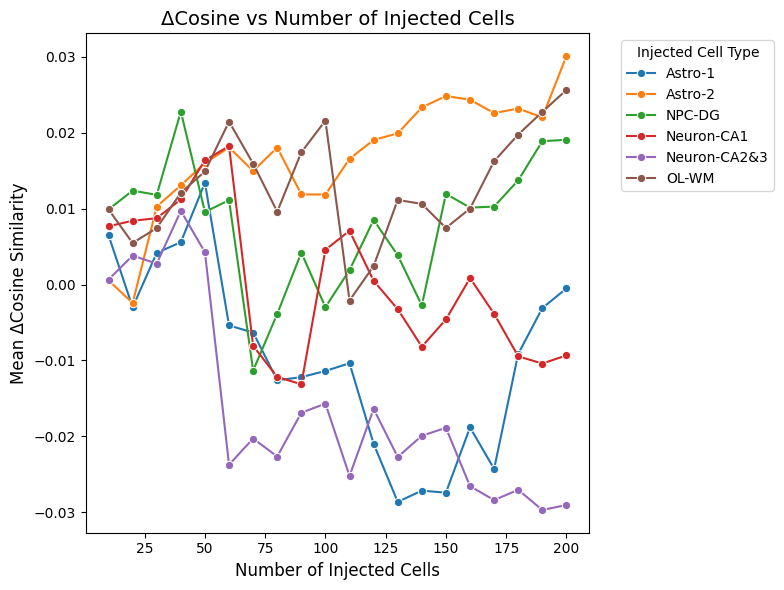

Figure saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig5_subfig/delta_cosine_injection_trend.pdf


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 按 n_inject 和 cell type 取均值
df_plot = df_all.groupby(["inject_ct", "n_inject"])["delta_cos"].mean().reset_index()

plt.figure(figsize=(8,6))
sns.lineplot(
    data=df_plot,
    x="n_inject", y="delta_cos",
    hue="inject_ct", marker="o"
)

plt.title("ΔCosine vs Number of Injected Cells", fontsize=14)
plt.xlabel("Number of Injected Cells", fontsize=12)
plt.ylabel("Mean ΔCosine Similarity", fontsize=12)
plt.legend(title="Injected Cell Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

out_fig_path = os.path.join(out_fig_dir, "delta_cosine_injection_trend.pdf")
plt.savefig(out_fig_path, format="pdf", dpi=300)
plt.show()

print(f"Figure saved to: {out_fig_path}")

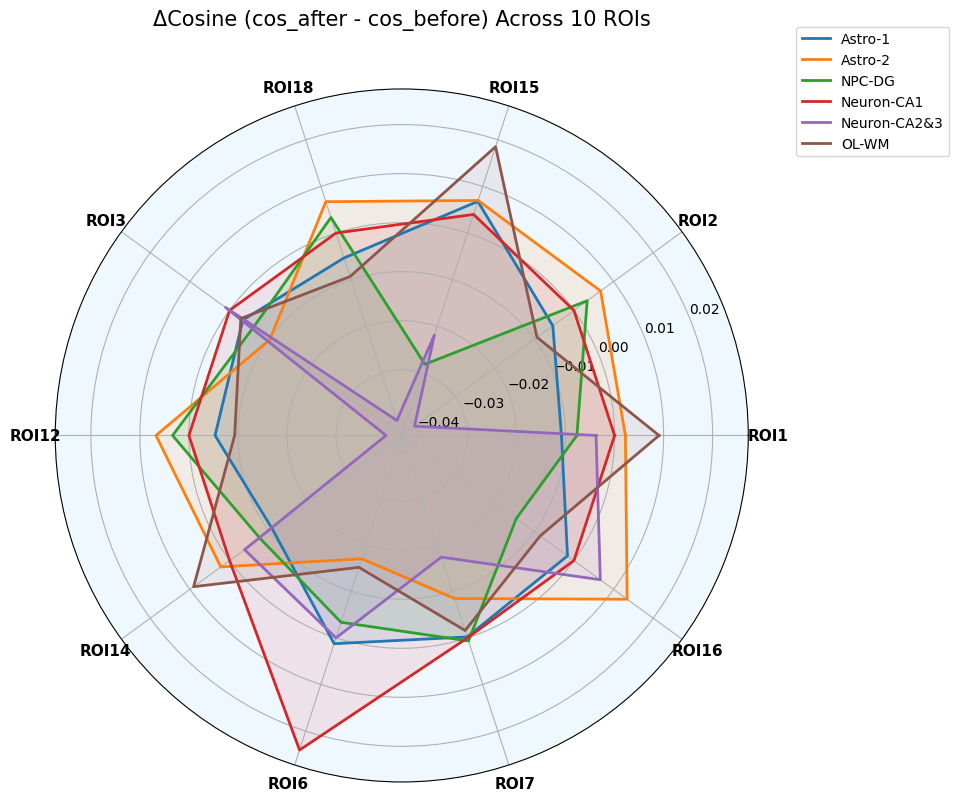

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Step 1: 定义文件路径 =====
base_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/ma2024_ROI_celltype_inject0916/ma2024_celltype_inject0916"
niche_dirs = [d for d in os.listdir(base_dir) if d.startswith("niche_")]

dfs = {}
for niche in niche_dirs:
    roi_name = niche.replace("niche_", "ROI")
    csv_path = os.path.join(base_dir, niche, f"{niche.replace('niche_', 'roi')}_metrics_niche_n100.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df["delta_cos"] = df["cos_after"] - df["cos_before"]
        dfs[roi_name] = df[["celltype", "delta_cos"]]

# ===== Step 2: 构建矩阵 (celltype × ROI) =====
celltypes = sorted(set().union(*[df["celltype"].unique() for df in dfs.values()]))
mat = pd.DataFrame(index=celltypes, columns=dfs.keys())

for roi, df in dfs.items():
    score_dict = dict(zip(df["celltype"], df["delta_cos"]))
    for ct in celltypes:
        mat.loc[ct, roi] = score_dict.get(ct, 0)

mat = mat.astype(float)

# ===== Step 3: 雷达图函数 =====
def plot_radar(mat, title, facecolor="#f5f5f5", save_path=None):
    categories = mat.columns.tolist()
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles.append(angles[0])

    fig = plt.figure(figsize=(9,9))
    ax = plt.subplot(111, polar=True)
    ax.set_facecolor(facecolor)

    for ct in mat.index:
        values = mat.loc[ct].tolist()
        values.append(values[0])
        ax.plot(angles, values, label=ct, linewidth=2)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight="bold")
    plt.title(title, size=15, y=1.08)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    if save_path:
        plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
        # plt.close(fig)
    else:
        plt.show()

# ===== Step 4: 绘制雷达图 =====
plot_radar(mat, "ΔCosine (cos_after - cos_before) Across 10 ROIs", facecolor="#f0f8ff",
           save_path="radar_delta_cos.pdf")